C:\Users\ragha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Predicted UTS: [1071.44]
Model Accuracy (R^2): -0.7121079682108133


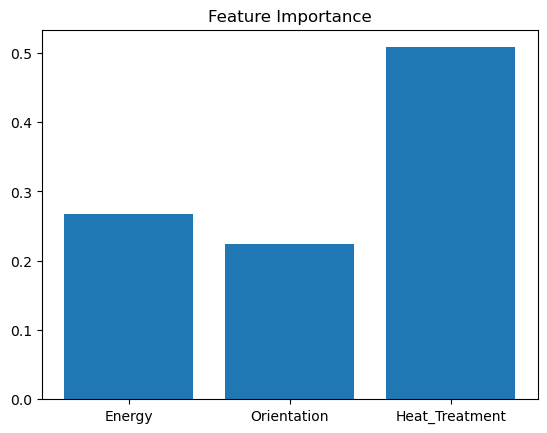

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

data = {
    "Energy": [59,59,59,59,59,59,59,59,83,70,60,110,85,55,75,68],
    "Orientation": ["XY","XZ","XY","XZ","Vertical","Vertical","Horizontal","Horizontal",
                    "NA","NA","NA","NA","NA","NA","NA","NA"],
    "Heat_Treatment": [0,0,1,1,0,1,0,1,0,0,0,0,0,0,0,0],
    "UTS": [994,877,1271,1178,900,1100,1012,1300,1150,1050,980,1200,1020,950,1100,1080]
}

df = pd.DataFrame(data)

le = LabelEncoder()
df["Orientation"] = le.fit_transform(df["Orientation"])

X = df[["Energy", "Orientation", "Heat_Treatment"]]
y = df["UTS"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

prediction = model.predict([[75, 0, 0]])  # example input
print("Predicted UTS:", prediction)


score = model.score(X_test, y_test)
print("Model Accuracy (R^2):", score)


importances = model.feature_importances_
features = ["Energy", "Orientation", "Heat_Treatment"]

plt.bar(features, importances)
plt.title("Feature Importance")
plt.show()

In [5]:
import pandas as pd

data = {
    "Energy": [50,55,60,65,70,75,80,85,90,95,100],
    "Orientation": ["XY","XY","XY","XY","XY","XY","XY","XY","XY","XY","XY"],
    "Heat_Treatment": [0,0,0,0,0,0,0,0,0,0,0],
    "UTS": [850,900,1000,1100,1200,1250,1200,1100,1000,900,800]
}

df = pd.DataFrame(data)

In [7]:
df = pd.get_dummies(df, columns=["Orientation"])

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop("UTS", axis=1)
y = df["UTS"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, n_estimators=200, random_state=42)

In [13]:
score = model.score(X_test, y_test)
print("R² Score:", score)

R² Score: 0.8379868421052632


In [15]:
new_data = pd.DataFrame({
    "Energy": [75],
    "Heat_Treatment": [0],
    "Orientation_XY": [1]
})

prediction = model.predict(new_data)
print("Predicted UTS:", prediction)

Predicted UTS: [1193.]


In [72]:
import pandas as pd

real_data = {
    "Energy": [59,59,59,59,59,59,59,59,83,70,60,110,85,55,75,68],
    "Orientation": ["XY","XZ","XY","XZ","Vertical","Vertical","Horizontal","Horizontal",
                    "NA","NA","NA","NA","NA","NA","NA","NA"],
    "Heat_Treatment": [0,0,1,1,0,1,0,1,0,0,0,0,0,0,0,0],
    "UTS": [994,877,1271,1178,900,1100,1012,1300,1150,1050,980,1200,1020,950,1100,1080]
}

df_real = pd.DataFrame(real_data)


synthetic_data = {
    "Energy": [50,55,60,65,70,75,80,85,90,95,100],
    "Orientation": ["XY"]*11,
    "Heat_Treatment": [0]*11,
    "UTS": [850,900,1000,1100,1200,1250,1200,1100,1000,900,800]
}

df_syn = pd.DataFrame(synthetic_data)


df = pd.concat([df_real, df_syn], ignore_index=True)


df = pd.get_dummies(df, columns=["Orientation"])


from sklearn.model_selection import train_test_split, cross_val_score

X = df[["Energy", "Heat_Treatment"]]
feature_columns = X.columns
y = df["UTS"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=10,
    random_state=42
)
model.fit(X, y)
print("Training R²:", model.score(X, y))
scores = cross_val_score(model, X, y, cv=4)
print("Cross-val R²:", scores)
print("Average R²:", scores.mean())



new_data = pd.DataFrame({
    "Energy": [59],
    "Heat_Treatment": [0],
    "Orientation_XY": [1]
})

# Add missing columns automatically
new_data = new_data.reindex(columns=feature_columns, fill_value=0)
prediction = model.predict(new_data)
print("Predicted UTS:", prediction)

Training R²: 0.8112345659839687
Cross-val R²: [ 0.42285715 -0.62286977  0.51149513 -0.17252073]
Average R²: 0.034740445447990764
Predicted UTS: [948.33533496]
